In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./cor_da_justica.csv")
df = df.drop(columns="Unnamed: 0", axis=1)

In [3]:
df = df.rename(columns={"ementa.1": "ementa_principal", "keywords.1": "keywords_principal"})

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11737 entries, 0 to 11736
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 11432 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    11737 non-null  int64 
 3   keywords               5072 non-null   object
 4   uris.uriAutores        11737 non-null  object
 5   uris.uriPropPrincipal  2242 non-null   object
 6   uris.uriUltimoRelator  3497 non-null   object
 7   nome                   11737 non-null  object
 8   cpf                    11737 non-null  int64 
 9   foto                   11737 non-null  object
 10  sexo                   11737 non-null  object
 11  nascimento             11737 non-null  object
 12  local_nascimento       11737 non-null  object
 13  escolaridade           11471 non-null  object
 14  uris.uriPartido        11737 non-null  object
 15  ementa_principal   

In [5]:
df.to_csv("cor_da_justica.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11737 entries, 0 to 11736
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 11432 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    11737 non-null  int64 
 3   keywords               5072 non-null   object
 4   uris.uriAutores        11737 non-null  object
 5   uris.uriPropPrincipal  2242 non-null   object
 6   uris.uriUltimoRelator  3497 non-null   object
 7   nome                   11737 non-null  object
 8   cpf                    11737 non-null  int64 
 9   foto                   11737 non-null  object
 10  sexo                   11737 non-null  object
 11  nascimento             11737 non-null  object
 12  local_nascimento       11737 non-null  object
 13  escolaridade           11471 non-null  object
 14  uris.uriPartido        11737 non-null  object
 15  ementa_principal   

In [7]:
palavra_chave = df["keywords"].value_counts().reset_index()
teste = palavra_chave["keywords"].apply(lambda x: x.split(','))
key_word = []
for key in teste:
    for word in key:
        key_word.append(word)

keyword = pd.DataFrame(key_word)

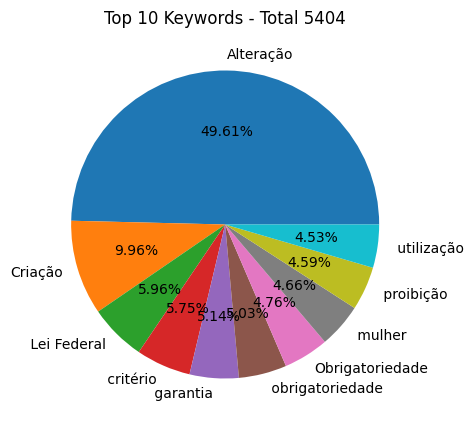

In [8]:
top10_keywords = keyword[0].value_counts().reset_index()
top10_keywords = top10_keywords.nlargest(10, "count")
fig, ax = plt.subplots(1,1,figsize=(12,5))
ax.pie(top10_keywords["count"], labels=top10_keywords[0],autopct="%.2f%%")
ax.set_title(f"Top 10 Keywords - Total {top10_keywords['count'].sum()}")
plt.show()


In [9]:
df["escolaridade"].unique()

array(['Superior', 'Ensino Fundamental', 'Mestrado', nan, 'Pós-Graduação',
       'Doutorado', 'Secundário', 'Superior Incompleto', 'Primário',
       'Doutorado Incompleto', 'Ensino Médio', 'Ensino Técnico',
       'Mestrado Incompleto', 'Primário Incompleto',
       'Ensino Médio Incompleto', 'Secundário Incompleto'], dtype=object)

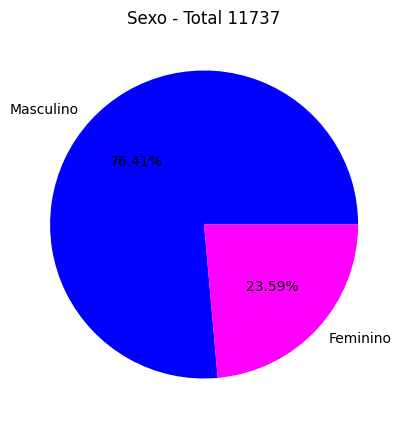

In [10]:
sexo = df["sexo"].value_counts().reset_index()
sexo["sexo"] = sexo["sexo"].map({"M": "Masculino", "F": "Feminino"})
fig, ax = plt.subplots(1,1,figsize=(12,5))
ax.pie(sexo["count"], labels=sexo["sexo"],autopct="%.2f%%", colors=["blue", "magenta",])
ax.set_title(f"Sexo - Total {sexo['count'].sum()}")
plt.show()

In [11]:
df_sem_cor = df["cor"].loc[(df["cor"] == "#NE") | (df["cor"] == "#NE#")]

In [12]:
df_sem_cor.reset_index(drop=True).count()

6314

In [13]:
df["cor"].loc[(df["cor"] == "NÃO DIVULGÁVEL")].count()

49